# ERK-KTR Full FOV Stimulation Pipeline -- Demo Microscope

Same pipeline as `stim_rtmsequence.ipynb`, but uses the **Micro-Manager demo
microscope** (`MMDemo`) with `ControllerSimulated` to load real pre-acquired
images from disk instead of the simulated camera output.

No real hardware required -- only a Micro-Manager installation with the
demo configuration.

In [1]:
import os
import tempfile

from rtm_pymmcore.core.data_structures import (
    Channel,
    SegmentationMethod,
    RTMSequence,
)
import rtm_pymmcore.core.utils as utils

## 1. Connect to the demo microscope

`MMDemo` loads the bundled Micro-Manager demo configuration.
Adjust `micromanager_path` if Micro-Manager is installed elsewhere.

In [2]:
from rtm_pymmcore.microscope.demo import MMDemo

mic = MMDemo(micromanager_path="C:\\Program Files\\Micro-Manager-2.0")

c:\Users\Jungfrau\Documents\alandolt\code\restructure_repo\rtm-pymmcore\.venv\Lib\site-packages\pymmcore_plus\core\_mmcore_plus.py:265: UserWarning: The current user-selected version of Micro-Manager at C:\Program Files\Micro-Manager-2.0 has an incompatible device interface (71). The installed version of pymmcore requires: 74). Clearing.
  self._mm_path = mm_path or find_micromanager()


## 2. Paths

`demo_data_path` points to the pre-acquired images (OME-Zarr + ref TIFFs).
`ControllerSimulated` will load from this path instead of using the demo camera.

`path` is the output directory where the pipeline writes results.

In [3]:
demo_data_path = os.path.join("..", "99_demo_data", "full_fov_stim")
if not os.path.isdir(demo_data_path):
    demo_data_path = os.path.join("experiments", "99_demo_data", "full_fov_stim")

path = os.path.join(tempfile.gettempdir(), "rtm-demo-full-fov-stim")
print(f"Demo data: {os.path.abspath(demo_data_path)}")
print(f"Output:    {path}")

Demo data: c:\Users\Jungfrau\Documents\alandolt\code\restructure_repo\rtm-pymmcore\experiments\99_demo_data\full_fov_stim
Output:    C:\Users\Jungfrau\AppData\Local\Temp\rtm-demo-full-fov-stim


## 3. Pipeline Setup

Identical components to the live `stim_rtmsequence.ipynb`:

- **Segmentation:** CellposeV4 on channel 0 (miRFP nuclear marker)
- **Tracking:** Trackpy with 50 px search range
- **Feature extraction:** ERK-KTR cytoplasmic/nuclear ratio
- **Stimulator:** Whole-FOV stimulation mask
- **Optocheck:** Reference channel feature extraction

In [4]:
from rtm_pymmcore.stimulation.base import StimWholeFOV
from rtm_pymmcore.tracking.trackpy import TrackerTrackpy
from rtm_pymmcore.feature_extraction.erk_ktr import FE_ErkKtr
from rtm_pymmcore.feature_extraction.optocheck import OptoCheckFE
from rtm_pymmcore.segmentation.cellpose_v4 import CellposeV4
from rtm_pymmcore.core.pipeline import ImageProcessingPipeline

segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=CellposeV4(),
        use_channel=0,
        save_tracked=True,
    )
]

stimulator = StimWholeFOV()
feature_extractor = FE_ErkKtr("labels")
tracker = TrackerTrackpy(search_range=50)
optocheck = OptoCheckFE(used_mask="labels")

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=stimulator,
    feature_extractor_ref=optocheck,
)

Directory C:\Users\Jungfrau\AppData\Local\Temp\rtm-demo-full-fov-stim\tracks already exists


In [5]:
# Channels matching the demo data (names don't need to exist in the demo
# config -- ControllerSimulated replaces the camera image anyway)
# group must match the demo microscope's channel group ("Channel")
imaging_channels = (
    Channel(config="DAPI", exposure=100, group="Channel"),  # stands in for miRFP
    Channel(config="FITC", exposure=100, group="Channel"),  # stands in for mScarlet3
)
optocheck_channel = Channel(
    config="Rhodamine", exposure=600, group="Channel"
)  # stands in for mCitrine

fov_positions = [
    {"x": 0.0, "y": 0.0, "z": 0.0},
    {"x": 100.0, "y": 0.0, "z": 0.0},
]

phase = RTMSequence(
    time_plan={"interval": 5.0, "loops": 3},
    stage_positions=fov_positions,
    channels=imaging_channels,
    ref_channels=(optocheck_channel,),
    ref_frames=[-1],
    rtm_metadata={
        "phase_name": "PostDrug",
        "phase_id": 1,
        "treatment_name": "Sustained Phase 2 post Drug",
    },
)

events = list(phase)
print(f"Total events: {len(events)}")
utils.events_to_dataframe(events)

Total events: 6


,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,ref_channels,stim,ref,phase_name,phase_id,treatment_name
0,0,0,0.0,0.0,0.0,0.0,"({'config': 'DAPI', 'exposure': 100.0, 'group'...",(),(),False,False,PostDrug,1,Sustained Phase 2 post Drug
1,1,0,0.0,100.0,0.0,0.0,"({'config': 'DAPI', 'exposure': 100.0, 'group'...",(),(),False,False,PostDrug,1,Sustained Phase 2 post Drug
2,0,1,5.0,0.0,0.0,0.0,"({'config': 'DAPI', 'exposure': 100.0, 'group'...",(),(),False,False,PostDrug,1,Sustained Phase 2 post Drug
3,1,1,5.0,100.0,0.0,0.0,"({'config': 'DAPI', 'exposure': 100.0, 'group'...",(),(),False,False,PostDrug,1,Sustained Phase 2 post Drug
4,0,2,10.0,0.0,0.0,0.0,"({'config': 'DAPI', 'exposure': 100.0, 'group'...",(),"({'config': 'Rhodamine', 'exposure': 600, 'gro...",False,True,PostDrug,1,Sustained Phase 2 post Drug
5,1,2,10.0,100.0,0.0,0.0,"({'config': 'DAPI', 'exposure': 100.0, 'group'...",(),"({'config': 'Rhodamine', 'exposure': 600, 'gro...",False,True,PostDrug,1,Sustained Phase 2 post Drug


## 5. Run the experiment

`ControllerSimulated` drives the demo microscope MDA engine but
**replaces every captured frame** with the corresponding real image
from `demo_data_path` (OME-Zarr for raw, TIFF for ref).

In [6]:
from rtm_pymmcore.core.controller import ControllerSimulated
from rtm_pymmcore.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

ctrl = ControllerSimulated(
    mic, pipeline, old_data_project_path=demo_data_path, writer=writer
)
ctrl.run_experiment(events)
ctrl.finish_experiment()

[ControllerSimulated] frameReady: img_type=ImgType.IMG_RAW fname=000_00000
[ControllerSimulated] frameReady: img_type=ImgType.IMG_RAW fname=001_00000


c:\Users\Jungfrau\Documents\alandolt\code\restructure_repo\rtm-pymmcore\.venv\Lib\site-packages\cellpose\dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


[ControllerSimulated] frameReady: img_type=ImgType.IMG_RAW fname=000_00001
[ControllerSimulated] frameReady: img_type=ImgType.IMG_RAW fname=001_00001
[ControllerSimulated] frameReady: img_type=ImgType.IMG_RAW fname=000_00002
[ControllerSimulated] frameReady: img_type=ImgType.IMG_RAW fname=001_00002


## 6. Inspect results

In [7]:
import pandas as pd

utils.generate_exp_data_from_tracks(path)
tracks = pd.read_parquet(os.path.join(path, "exp_data.parquet"))
print(
    f"Tracked {tracks['particle'].nunique()} cells across {tracks['timestep'].nunique()} frames"
)
tracks.head(10)

Tracked 134 cells across 3 frames


,label,x,y,phase_name,phase_id,treatment_name,fov,timestep,fname,time,...,mean_intensity_C1_nuc,area_nuc,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,median_intensity_C0_ring,median_intensity_C1_ring,cnr,cnr_median
0,1,6.256055,172.629758,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,487.294118,289.0,312.0,485.0,194.901961,457.196078,192.5,455.5,0.938234,0.939175
1,2,11.702303,516.865132,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,609.725329,608.0,742.5,586.0,215.839744,837.391026,215.0,837.5,1.373391,1.429181
2,4,7.550861,826.090767,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,703.327074,639.0,807.0,701.0,212.380282,656.049296,207.5,649.5,0.932780,0.926534
3,5,14.309091,675.351515,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,797.651515,330.0,532.0,791.0,212.722222,789.197531,211.5,800.0,0.989401,1.011378
4,6,27.867176,101.212214,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,390.806107,655.0,341.0,390.0,193.644860,410.280374,193.0,406.0,1.049831,1.041026
5,7,24.868354,717.870886,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,750.027848,395.0,444.0,746.0,210.329480,708.121387,209.0,689.0,0.944127,0.923593
6,8,27.549451,195.338828,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,525.509158,546.0,599.0,523.0,201.654822,539.522843,200.0,549.0,1.026667,1.049713
7,9,32.121053,267.444737,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,520.573684,380.0,355.0,503.5,209.682081,623.705202,209.0,512.0,1.198111,1.016882
8,10,36.937653,477.360636,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,666.754279,818.0,698.5,649.0,222.754310,833.189655,221.0,824.5,1.249620,1.270416
9,11,42.810282,629.465116,PostDrug,1,Sustained Phase 2 post Drug,0,0,000_00000,0.0,...,1582.123623,817.0,586.0,1521.0,220.875536,2209.210300,218.0,2232.0,1.396358,1.467456


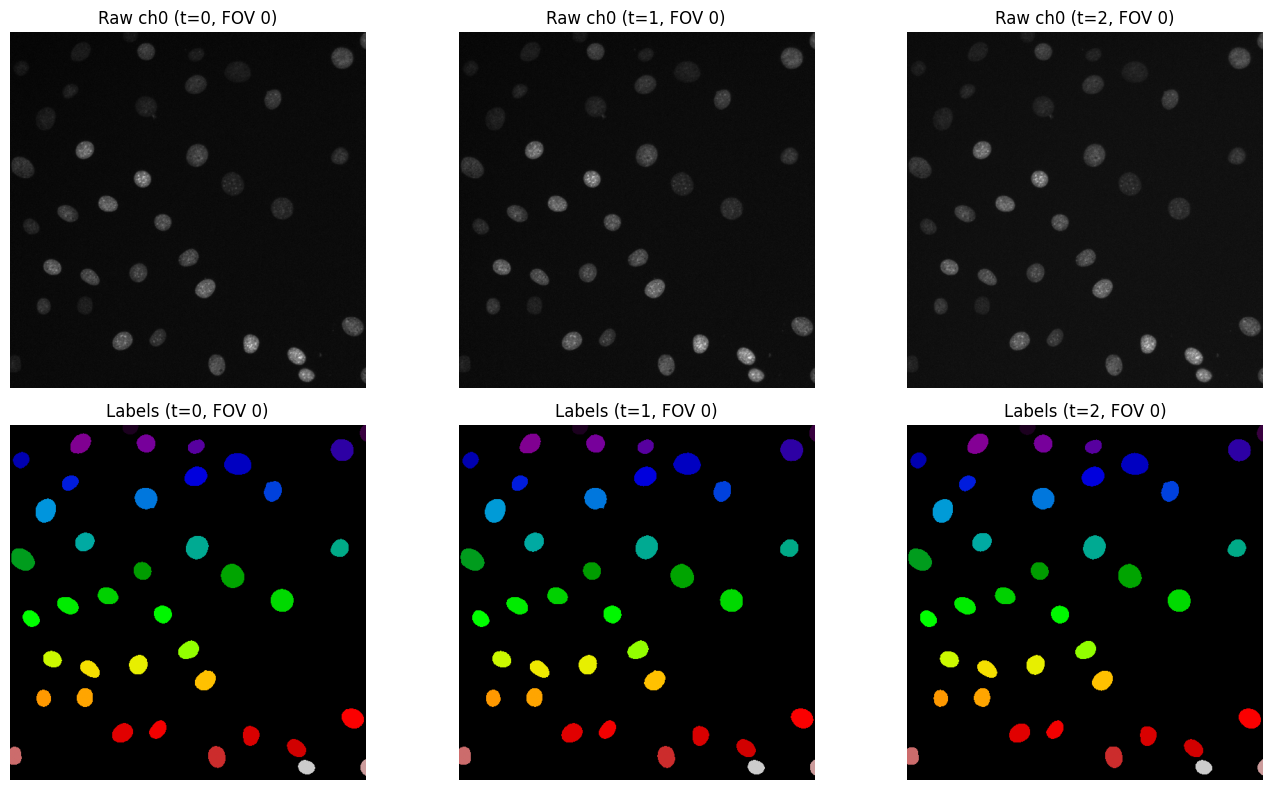

In [8]:
import matplotlib.pyplot as plt
import zarr

store = zarr.open_group(os.path.join(path, "acquisition.ome.zarr"), mode="r")
raw = store["0"]
lbl = store["labels/labels/0"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for t in range(min(3, raw.shape[0])):
    axes[0, t].imshow(raw[t, 0, 0], cmap="gray")
    axes[0, t].set_title(f"Raw ch0 (t={t}, FOV 0)")
    axes[1, t].imshow(lbl[t, 0], cmap="nipy_spectral")
    axes[1, t].set_title(f"Labels (t={t}, FOV 0)")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()